# FOA Spatial Targets — Route A (vMF Intensity Splat) vs Route B (Capon / MVDR)

ACN/SN3D ambiX `[W, Y, Z, X]`. Per `fshape x tshape` mel TF-patch we build a DOA
probability distribution on a Fibonacci sphere to self-supervise the DoA branch.

**Route B is Capon/MVDR** (`q ∝ (aᴴRl⁻¹a)^(-sharp)`), not MUSIC. MUSIC collapsed to a
flat pseudospectrum on real reverberant FOA (eigen-gap source-counting returns K=0 →
noise subspace = whole space → `q` = bare first-order beampattern, a broad blob).
Capon needs no source-counting, is robust to the first-order model mismatch, points to
the dominant DOA in every regime, and resolves well-separated multi-source patches.

In [1]:
import math
import random
import torch
import torch.nn.functional as F
from torch import nn, Tensor
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import torchaudio
import torchaudio.functional as TAF
from torchaudio.transforms import Spectrogram, MelScale
from torchaudio.functional import melscale_fbanks
from scipy.spatial import ConvexHull
from typing import Callable


# Shared Fibonacci grid (front=x, left=y, up=z). Used by BOTH routes.
def fibonacci_sphere(n: int) -> Tensor:
    i = torch.arange(n, dtype=torch.float64)
    z = 1.0 - 2.0 * (i + 0.5) / n
    r = torch.sqrt(torch.clamp(1.0 - z * z, min=0.0))
    phi = math.pi * (3.0 - math.sqrt(5.0))
    theta = phi * i
    x = r * torch.cos(theta)
    y = r * torch.sin(theta)
    return torch.stack([x, y, z], dim=1).float()

In [2]:
# ---------- 1. Feature Extractor ----------
class FeatureExtractor(nn.Module):
    """8-channel FOA features for ACN/SN3D ambiX [W, Y, Z, X]."""
    def __init__(self, sample_rate=32000, n_fft=1024, win_length=1024,
                 hop_length=None, f_min=50.0, f_max=None, n_mels=128,
                 power=2.0, mel_scale="htk",
                 diffuseness_tau_t=11, diffuseness_tau_f=3, diffuseness_c=1.0,
                 window_fn: Callable[..., Tensor] = torch.hann_window):
        super().__init__()
        self.eps = 1e-6
        self.power = power
        self.hop_length = hop_length or (win_length // 2)
        self.tau_t = diffuseness_tau_t
        self.tau_f = diffuseness_tau_f
        self.c = diffuseness_c
        assert self.tau_t % 2 == 1 and self.tau_f % 2 == 1

        self.spectrogram = Spectrogram(n_fft=n_fft, win_length=win_length,
                                       hop_length=self.hop_length, power=None,
                                       window_fn=window_fn, center=True,
                                       pad_mode="reflect", onesided=True)

        f_max = f_max if f_max is not None else sample_rate // 2
        self.mel_scale = MelScale(n_mels, sample_rate, f_min, f_max,
                                  n_fft // 2 + 1, None, mel_scale)

    def _intensity_energy(self, spec):
        W = spec[:, [0]]
        YZX = spec[:, 1:]
        I = 2.0 * torch.real(torch.conj(W) * YZX)
        E = torch.abs(W) ** 2 + (torch.abs(YZX) ** 2).sum(1, keepdim=True)
        return I, E

    def _tf_smooth(self, x):
        return F.avg_pool2d(x, (self.tau_f, self.tau_t), stride=1,
                            padding=(self.tau_f // 2, self.tau_t // 2),
                            count_include_pad=False)

    def _diffuseness(self, intensity_mel, energy_mel):
        I = self._tf_smooth(intensity_mel.float())
        E = self._tf_smooth(energy_mel.float())
        num = torch.linalg.norm(I, dim=1, keepdim=True)
        psi = 1.0 - num / (self.c * E + self.eps)
        return psi.clamp(0.0, 1.0)

    def extract_all(self, audio: Tensor) -> dict:
        spec = self.spectrogram(audio)
        logmel = torch.log(self.mel_scale(torch.abs(spec) ** self.power) + self.eps)
        I, E = self._intensity_energy(spec)
        intensity_mel = self.mel_scale(I)
        energy_mel = self.mel_scale(E)
        aiv = intensity_mel / (energy_mel + self.eps)
        diffuseness = self._diffuseness(intensity_mel, energy_mel)
        return dict(spec=spec, logmel=logmel, aiv=aiv, intensity_mel=intensity_mel,
                    energy_mel=energy_mel, diffuseness=diffuseness)

In [3]:
# ---------- 2a. Route A Target (vMF Intensity Splat) ----------
class MelPatchTargetGenerator(nn.Module):
    def __init__(self, n_grid=512, kappa=40.0, fshape=16, tshape=8,
                 tile_f=1, tile_t=1, eps=1e-6, n_mels=128, f_min=50.0,
                 f_max=None, sample_rate=32000, n_fft=1024):
        super().__init__()
        self.n_grid = n_grid
        self.kappa = kappa
        self.fshape = fshape
        self.tshape = tshape
        self.tile_f = tile_f
        self.tile_t = tile_t
        self.eps = eps

        if f_max is None: 
            f_max = sample_rate / 2.0
        mel_fb = melscale_fbanks(n_fft // 2 + 1, f_min, f_max, n_mels, sample_rate, norm="slaney").transpose(0, 1).float()
        self.register_buffer("mel_fb", mel_fb)
        self.register_buffer("G", fibonacci_sphere(n_grid))

    @torch.no_grad()
    def forward(self, stft_spec):
        B, C, F_stft, T_stft = stft_spec.shape
        W = stft_spec[:, [0]]
        YZX = stft_spec[:, 1:]
        I_stft = 2.0 * torch.real(torch.conj(W) * YZX)
        I_mel = torch.einsum("mf,bcft->bcmt", self.mel_fb, I_stft)
        I_xyz = I_mel[:, [2, 0, 1], :, :]

        if self.tile_f > 1 or self.tile_t > 1:
            I_xyz = F.avg_pool2d(I_xyz, (self.tile_f, self.tile_t), stride=1, padding=(self.tile_f // 2, self.tile_t // 2), count_include_pad=False)[..., :, :]

        Inorm = torch.linalg.norm(I_xyz, dim=1)
        dir_xyz = I_xyz / Inorm.unsqueeze(1).clamp_min(self.eps)
        cos = torch.einsum("gd,bdmt->bgmt", self.G, dir_xyz)
        vmf = torch.exp(self.kappa * cos)
        wvmf = Inorm.unsqueeze(1) * vmf

        area = self.fshape * self.tshape
        q = F.avg_pool2d(wvmf, kernel_size=(self.fshape, self.tshape), stride=(self.fshape, self.tshape)) * area
        Wp = F.avg_pool2d(Inorm.unsqueeze(1), kernel_size=(self.fshape, self.tshape), stride=(self.fshape, self.tshape)).squeeze(1) * area

        Nf, Nt = q.shape[-2], q.shape[-1]
        q_all = q.permute(0, 2, 3, 1).reshape(B, Nf * Nt, -1)
        Wp_all = Wp.reshape(B, Nf * Nt)
        q_all = q_all / q_all.sum(dim=-1, keepdim=True).clamp_min(self.eps)
        return q_all, Wp_all

In [4]:
# ---------- 2b. Route B Target (Covariance + Capon / MVDR) ----------
class RouteBTargetMel(nn.Module):
    """COMPASS-style per-patch DOA distribution on the MEL scale, via Capon/MVDR.

    Drop-in for Route A: returns (q, Wp) of shape (B,P,|G|),(B,P) on the SAME grid
    and SAME freq-major patch order. Input is the COMPLEX linear STFT (B,4,F,T).

    Mel-band covariance: a covariance is bilinear in the spectra, so mel-pool the
    cross-spectral density, not magnitudes:  R_mel(m,t)_cd = sum_f fb[f,m] X_c conj(X_d).
    Summing fshape mel bands x tshape frames gives the patch covariance R.

    Per patch:
      Rw = D^-1/2 R D^-1/2                  (SN3D diffuse-field whitening)
      Rl = Rw + load * tr(Rw)/4 * I         (diagonal loading)
      q(g) propto ( a_g^H Rl^-1 a_g )^-sharp  (Capon, sharpened, normalised)
      Wp = || 2 Re[R_WY, R_WZ, R_WX] ||      (directional intensity; ~0 if diffuse)
    """
    def __init__(self, n_grid: int = 512, n_mels: int = 128, fshape: int = 16,
                 tshape: int = 8, kappa: float = 40.0, sharp: float = 2.5,
                 load: float = 0.02, silence_rel: float = 2e-3, eps: float = 1e-6,
                 sample_rate=32000, n_fft=1024, f_min=50.0, f_max=None,
                 mel_norm="slaney", mel_scale="htk"):
        super().__init__()
        self.n_mels = n_mels
        self.fshape, self.tshape = fshape, tshape
        self.sharp, self.load = float(sharp), float(load)
        self.silence_rel, self.eps = silence_rel, eps
        self.kappa = kappa  # kept for API parity with Route A (unused by Capon)

        if f_max is None: f_max = sample_rate / 2.0
        mel_fb = melscale_fbanks(n_fft // 2 + 1, f_min, f_max, n_mels,
                                 sample_rate, norm=mel_norm,
                                 mel_scale=mel_scale).transpose(0, 1).float()
        self.register_buffer("mel_fb", mel_fb.to(torch.complex64))   # (n_mels, F)

        G = fibonacci_sphere(n_grid)
        self.register_buffer("G", G)
        x, y, z = G[:, 0], G[:, 1], G[:, 2]
        A = torch.stack([torch.ones_like(x), y, z, x], dim=1)        # (|G|,4) [W,Y,Z,X]
        wh = torch.tensor([1.0, math.sqrt(3.0), math.sqrt(3.0), math.sqrt(3.0)])
        Aw = A * wh[None, :]
        Aw = Aw / Aw.norm(dim=1, keepdim=True).clamp_min(eps)
        self.register_buffer("Aw", Aw.to(torch.complex64))           # (|G|,4)
        self.register_buffer("whiten", torch.diag(wh).to(torch.complex64))

    @torch.no_grad()
    def forward(self, spec: Tensor):
        B, C, Fr, T = spec.shape
        eps = self.eps
        ts = self.tshape
        Nt = T // ts
        Nf = self.n_mels // self.fshape
        P = Nf * Nt

        Z = spec[:, :, :, :Nt * ts].to(torch.complex64)
        Z_t = Z.view(B, 4, Fr, Nt, ts)
        # per-linear-bin covariance over tshape frames -> mel-pool -> sum fshape bands
        R_lin = torch.einsum("bcftj,bdftj->bftcd", Z_t, Z_t.conj())   # (B,F,Nt,4,4)
        R_mel = torch.einsum("mf,bftcd->bmtcd", self.mel_fb, R_lin)   # (B,n_mels,Nt,4,4)
        R = R_mel.view(B, Nf, self.fshape, Nt, 4, 4).sum(2).reshape(B, P, 4, 4)

        # confidence weight from patch active intensity: I = 2 Re[R_WY,R_WZ,R_WX]
        I_yzx = 2.0 * R[..., 0, 1:].real                             # (B,P,3)
        Wp = torch.linalg.norm(I_yzx, dim=-1)                        # (B,P)

        # whiten + diagonal loading
        Wh = self.whiten
        Rw = Wh @ R @ Wh.conj().t()
        tr = torch.diagonal(Rw, dim1=-2, dim2=-1).sum(-1).real
        load = self.load * (tr / 4.0).clamp_min(eps)
        I4 = torch.eye(4, dtype=Rw.dtype, device=Rw.device)
        Rl = Rw + load[..., None, None] * I4

        # Capon / MVDR pseudospectrum
        Rinv = torch.linalg.inv(Rl)
        Aw = self.Aw
        tmp = torch.einsum("gi,apij->apgj", Aw.conj(), Rinv)         # (B,P,|G|,4)
        base = torch.einsum("apgj,gj->apg", tmp, Aw).real.clamp_min(eps)
        q = base.pow(-self.sharp)
        q = q / q.sum(-1, keepdim=True).clamp_min(eps)

        # silence gate on Wp (q on silent patches is ~uniform, harmless)
        floor = self.silence_rel * tr.amax(dim=1, keepdim=True).clamp_min(eps)
        Wp = torch.where(tr > floor, Wp, torch.zeros_like(Wp))
        return q, Wp

In [14]:
# ---------- 3. Load Real Audio File & Resample ----------
filepath = "/projects/0/prjs1261/seld/foa_dev/dev-train-sony/fold3_room21_mix023.wav"

try:
    audio_full, orig_sr = torchaudio.load(filepath)
    print(f"Loaded {filepath} (Original SR: {orig_sr} Hz, Shape: {audio_full.shape})")
except Exception as e:
    raise RuntimeError(f"Could not load audio file. Please check the path.\n{e}")

TARGET_SR = 32000
if orig_sr != TARGET_SR:
    audio_full = TAF.resample(audio_full, orig_freq=orig_sr, new_freq=TARGET_SR)
sr = TARGET_SR

duration = 5.0
n_samples = int(duration * sr)
if audio_full.shape[1] > n_samples:
    start_idx = random.randint(0, audio_full.shape[1] - n_samples)
    audio = audio_full[:, start_idx : start_idx + n_samples]
else:
    audio = audio_full
audio = audio.unsqueeze(0)

Loaded /projects/0/prjs1261/seld/foa_dev/dev-train-sony/fold3_room21_mix023.wav (Original SR: 24000 Hz, Shape: torch.Size([4, 2628000]))


In [15]:
# ---------- 4. Extract Features & Run Both Targets ----------
n_mels, fshape, tshape = 128, 16, 8
n_fft = 1024
hop_length = n_fft // 2
SHARP = 2.5          # Route B target tightness (try 2-4)
LOAD  = 0.02         # Route B MVDR diagonal loading (robustness)

extractor = FeatureExtractor(sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)

tgt_gen_a = MelPatchTargetGenerator(n_grid=512, kappa=40.0, fshape=fshape, tshape=tshape,
                                    n_mels=n_mels, sample_rate=sr, n_fft=n_fft)
tgt_gen_b = RouteBTargetMel(n_grid=512, n_mels=n_mels, fshape=fshape, tshape=tshape,
                            sample_rate=sr, n_fft=n_fft, sharp=SHARP, load=LOAD)

extractor.eval(); tgt_gen_a.eval(); tgt_gen_b.eval()

with torch.no_grad():
    features = extractor.extract_all(audio)
    stft_spec = features['spec']
    logmel_W = features['logmel'][0, 0].numpy()
    diff_map = features['diffuseness'][0, 0].numpy()

    q_all_a, Wp_all_a = tgt_gen_a(stft_spec)
    q_all_b, Wp_all_b = tgt_gen_b(stft_spec)

Nf_patches = n_mels // fshape
Nt_patches = logmel_W.shape[1] // tshape

# Wp is now ||patch active intensity|| -> argmax lands on a DIRECTIONAL patch.
Wp_flat = Wp_all_b[0].clone()
idx1 = torch.argmax(Wp_flat).item()
patch1_f = idx1 // Nt_patches
patch1_t = idx1 % Nt_patches

q1_route_a = q_all_a[0, idx1].numpy()
q1_route_b = q_all_b[0, idx1].numpy()
print(f"Comparing on Patch {idx1} -> Freq block {patch1_f}, Time block {patch1_t}")

Comparing on Patch 51 -> Freq block 1, Time block 12


In [16]:
# ---------- 5. Multi-Panel Interactive Dashboard ----------
G = tgt_gen_b.G.numpy()
X, Y, Z = G[:, 0], G[:, 1], G[:, 2]
az_deg, el_deg = np.degrees(np.arctan2(Y, X)) % 360, np.degrees(np.arcsin(Z))
hull = ConvexHull(G)
i_mesh, j_mesh, k_mesh = hull.simplices[:, 0], hull.simplices[:, 1], hull.simplices[:, 2]

fig = make_subplots(
    rows=2, cols=2,
    specs=[[{'type': 'xy'}, {'type': 'xy'}],
           [{'type': 'scene'}, {'type': 'scene'}]],
    subplot_titles=(
        "Log-Mel Spectrogram (Channel W)",
        "Diffuseness Map",
        f"Route A (vMF Splat) - Patch {idx1}",
        f"Route B (Capon/MVDR, sharp={SHARP}) - Patch {idx1}"
    ),
    vertical_spacing=0.15
)

def add_patch_box(fig, p_t, p_f, color, label, row, col):
    x0, x1 = p_t * tshape, (p_t + 1) * tshape
    y0, y1 = p_f * fshape, (p_f + 1) * fshape
    fig.add_shape(type="rect", x0=x0, y0=y0, x1=x1, y1=y1,
                  line=dict(color=color, width=3), row=row, col=col)
    fig.add_annotation(x=x1, y=y1+3, text=label, showarrow=False,
                       font=dict(color=color, size=14), row=row, col=col)

def add_doa_marker(fig, q, row, col):
    g = int(q.argmax())
    fig.add_trace(go.Scatter3d(x=[G[g,0]*1.12], y=[G[g,1]*1.12], z=[G[g,2]*1.12],
                  mode="markers", marker=dict(size=6, color="lime", symbol="diamond"),
                  showlegend=False, hoverinfo="skip"), row=row, col=col)

# Row 1 Col 1: Log-Mel W
fig.add_trace(go.Heatmap(z=logmel_W, colorscale='Magma', colorbar=dict(title="Log-Mel", x=0.45, y=0.8, len=0.4)), row=1, col=1)
add_patch_box(fig, patch1_t, patch1_f, "cyan", "Target Patch", row=1, col=1)

# Row 1 Col 2: Diffuseness
fig.add_trace(go.Heatmap(z=diff_map, zmin=0, zmax=1, colorscale='Viridis', colorbar=dict(title="Diffuseness", x=1.0, y=0.8, len=0.4)), row=1, col=2)
add_patch_box(fig, patch1_t, patch1_f, "cyan", "Target Patch", row=1, col=2)

# Row 2 Col 1: Route A
fig.add_trace(go.Mesh3d(x=X, y=Y, z=Z, i=i_mesh, j=j_mesh, k=k_mesh, color='gray', opacity=0.1, alphahull=0, showscale=False, hoverinfo='skip'), row=2, col=1)
fig.add_trace(go.Scatter3d(x=X, y=Y, z=Z, mode='markers',
                           marker=dict(size=4, color=q1_route_a, colorscale='Plasma', colorbar=dict(title="Prob A", x=0.45, y=0.2, len=0.4)),
                           text=[f"Az:{a:.1f}, El:{e:.1f}<br>P:{p:.4f}" for a,e,p in zip(az_deg, el_deg, q1_route_a)], hoverinfo="text"), row=2, col=1)
add_doa_marker(fig, q1_route_a, 2, 1)

# Row 2 Col 2: Route B
fig.add_trace(go.Mesh3d(x=X, y=Y, z=Z, i=i_mesh, j=j_mesh, k=k_mesh, color='gray', opacity=0.1, alphahull=0, showscale=False, hoverinfo='skip'), row=2, col=2)
fig.add_trace(go.Scatter3d(x=X, y=Y, z=Z, mode='markers',
                           marker=dict(size=4, color=q1_route_b, colorscale='Plasma', colorbar=dict(title="Prob B", x=1.0, y=0.2, len=0.4)),
                           text=[f"Az:{a:.1f}, El:{e:.1f}<br>P:{p:.4f}" for a,e,p in zip(az_deg, el_deg, q1_route_b)], hoverinfo="text"), row=2, col=2)
add_doa_marker(fig, q1_route_b, 2, 2)

no_axis = dict(showbackground=False, showgrid=False, zeroline=False, showticklabels=False, title='')
fig.update_layout(
    height=900, width=1100, template="plotly_dark",
    scene=dict(xaxis=no_axis, yaxis=no_axis, zaxis=no_axis),
    scene2=dict(xaxis=no_axis, yaxis=no_axis, zaxis=no_axis),
    margin=dict(l=20, r=20, b=20, t=60),
    title=f"Head-to-Head: Route A (vMF) vs Route B (Capon/MVDR, sharp={SHARP})<br><sup>{filepath.split('/')[-1]}</sup>"
)
fig.update_xaxes(title_text="Time Frames", row=1)
fig.update_yaxes(title_text="Mel Bands", row=1)
fig.show()

In [51]:
# ---------- Synthetic FOA scene with known ground truth ----------
def make_foa(sources, sr=32000, dur=2.0, seed=42, noise=0.05, drift=0.1):
    # sources: list of (az_deg, el_deg, freq_hz). Independent phase drift per
    # source -> incoherent -> rank-2 covariance when they share a band.
    n = int(dur * sr); t = torch.arange(n, dtype=torch.float32) / sr
    g = torch.Generator().manual_seed(seed)
    audio = torch.zeros(1, 4, n)
    for az, el, f in sources:
        phase = torch.cumsum(torch.randn(n, generator=g) * drift, dim=0)
        s = torch.sin(2 * math.pi * f * t + phase)
        ar, er = math.radians(az), math.radians(el)
        audio[0, 0] += s
        audio[0, 1] += s * math.cos(er) * math.sin(ar)   # Y
        audio[0, 2] += s * math.sin(er)                  # Z
        audio[0, 3] += s * math.cos(er) * math.cos(ar)   # X
    audio += torch.randn(audio.shape, generator=g) * noise
    return audio

sr, n_fft, hop = 32000, 1024, 320
n_mels, fshape, tshape = 128, 16, 8
SHARP, LOAD = 2.5, 0.02

# OVERLAP scene: two incoherent sources, SAME frequency -> same mel patch
F0 = 450.0
TRUE = [(0, 0, F0), (60, 0, F0 + 400.0)]
audio = make_foa(TRUE, sr=sr, dur=2.0, noise=0.05, drift=0.10)

extractor = FeatureExtractor(sr, n_fft=n_fft, hop_length=hop, n_mels=n_mels).eval()
routeA = MelPatchTargetGenerator(n_grid=512, fshape=fshape, tshape=tshape, n_mels=n_mels,
                                 sample_rate=sr, n_fft=n_fft).eval()
routeB = RouteBTargetMel(n_grid=512, fshape=fshape, tshape=tshape, n_mels=n_mels,
                         sample_rate=sr, n_fft=n_fft, sharp=SHARP, load=LOAD).eval()

with torch.no_grad():
    feats = extractor.extract_all(audio)
    spec = feats['spec']
    logmel_W = feats['logmel'][0, 0].numpy()
    diff_map = feats['diffuseness'][0, 0].numpy()
    qA_all, WpA = routeA(spec)
    qB_all, WpB = routeB(spec)

Nf_p, Nt_p = n_mels // fshape, logmel_W.shape[1] // tshape
freqs_Hz = torch.arange(0, n_fft // 2 + 1) * sr / n_fft
band = routeB.mel_fb.real[:, torch.argmin(torch.abs(freqs_Hz - F0)).item()].argmax().item()
pf = band // fshape
pt = int(torch.argmax(WpB[0].view(Nf_p, Nt_p)[pf]).item())   # most directional time-patch in that band
pid = pf * Nt_p + pt
qA, qB = qA_all[0, pid].numpy(), qB_all[0, pid].numpy()
print(f"source band -> freq-patch {pf}, time-patch {pt} (patch {pid}); true az = -60, +60")

source band -> freq-patch 1, time-patch 2 (patch 27); true az = -60, +60


In [52]:
# ---------- Recovered DOAs (azimuth, both at el~0) ----------
G = routeB.G.numpy()
az_g = np.degrees(np.arctan2(G[:, 1], G[:, 0]))
el_g = np.degrees(np.arcsin(np.clip(G[:, 2], -1, 1)))

def top2_az(q, sep=25):
    order = np.argsort(q)[::-1]; picks = []
    for i in order:
        if all(abs(((az_g[i]-az_g[j]+180) % 360)-180) > sep for j in picks): picks.append(i)
        if len(picks) == 2: break
    return sorted(round(az_g[p]) for p in picks)

print(f"Route A  (vMF)   recovered az: {top2_az(qA)}")
print(f"Route B  (Capon) recovered az: {top2_az(qB)}")

Route A  (vMF)   recovered az: [7, 59]
Route B  (Capon) recovered az: [7, 39]


In [53]:
# ---------- Dashboard: spheres + ground-truth markers ----------
X, Y, Z = G[:, 0], G[:, 1], G[:, 2]
az_deg, el_deg = np.degrees(np.arctan2(Y, X)) % 360, np.degrees(np.arcsin(np.clip(Z, -1, 1)))
hull = ConvexHull(G); im, jm, km = hull.simplices[:, 0], hull.simplices[:, 1], hull.simplices[:, 2]
gt_dirs = [(math.cos(math.radians(a)), math.sin(math.radians(a)), 0.0) for a, e, f in TRUE]

fig = make_subplots(rows=2, cols=2,
    specs=[[{'type': 'xy'}, {'type': 'xy'}], [{'type': 'scene'}, {'type': 'scene'}]],
    subplot_titles=("Log-Mel (W)", "Diffuseness",
                    "Route A (vMF) — overlap patch", f"Route B (Capon, sharp={SHARP}) — overlap patch"),
    vertical_spacing=0.13)

def box(p_t, p_f, row, col):
    fig.add_shape(type="rect", x0=p_t*tshape, y0=p_f*fshape, x1=(p_t+1)*tshape, y1=(p_f+1)*fshape,
                  line=dict(color="cyan", width=3), row=row, col=col)
def sphere(q, cb_x, row, col):
    fig.add_trace(go.Mesh3d(x=X, y=Y, z=Z, i=im, j=jm, k=km, color='gray', opacity=0.1,
                            alphahull=0, showscale=False, hoverinfo='skip'), row=row, col=col)
    fig.add_trace(go.Scatter3d(x=X, y=Y, z=Z, mode='markers',
        marker=dict(size=4, color=q, colorscale='Plasma', colorbar=dict(title="P", x=cb_x, y=0.2, len=0.4)),
        text=[f"Az:{a:.0f} El:{e:.0f}<br>P:{p:.4f}" for a, e, p in zip(az_deg, el_deg, q)],
        hoverinfo="text"), row=row, col=col)
    for gx, gy, gz in gt_dirs:                       # cyan diamonds = true DOAs
        fig.add_trace(go.Scatter3d(x=[gx*1.15], y=[gy*1.15], z=[gz*1.15], mode="markers",
            marker=dict(size=7, color="cyan", symbol="diamond"), showlegend=False, hoverinfo="skip"),
            row=row, col=col)

fig.add_trace(go.Heatmap(z=logmel_W, colorscale='Magma', colorbar=dict(title="dB", x=0.45, y=0.8, len=0.4)), row=1, col=1); box(pt, pf, 1, 1)
fig.add_trace(go.Heatmap(z=diff_map, zmin=0, zmax=1, colorscale='Viridis', colorbar=dict(title="psi", x=1.0, y=0.8, len=0.4)), row=1, col=2); box(pt, pf, 1, 2)
sphere(qA, 0.45, 2, 1); sphere(qB, 1.0, 2, 2)
no_axis = dict(showbackground=False, showgrid=False, zeroline=False, showticklabels=False, title='')
fig.update_layout(height=900, width=1100, template="plotly_dark",
                  scene=dict(xaxis=no_axis, yaxis=no_axis, zaxis=no_axis),
                  scene2=dict(xaxis=no_axis, yaxis=no_axis, zaxis=no_axis),
                  margin=dict(l=20, r=20, b=20, t=70),
                  title="Overlap scene through the pipeline — cyan diamonds = true DOA (-60, +60)")
fig.update_xaxes(title_text="Time", row=1); fig.update_yaxes(title_text="Mel", row=1)
fig.show()

In [48]:
import math, torch
import torch.nn.functional as F
from torch import nn, Tensor
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
from torchaudio.transforms import Spectrogram, MelScale
from torchaudio.functional import melscale_fbanks
from scipy.spatial import ConvexHull
from typing import Callable


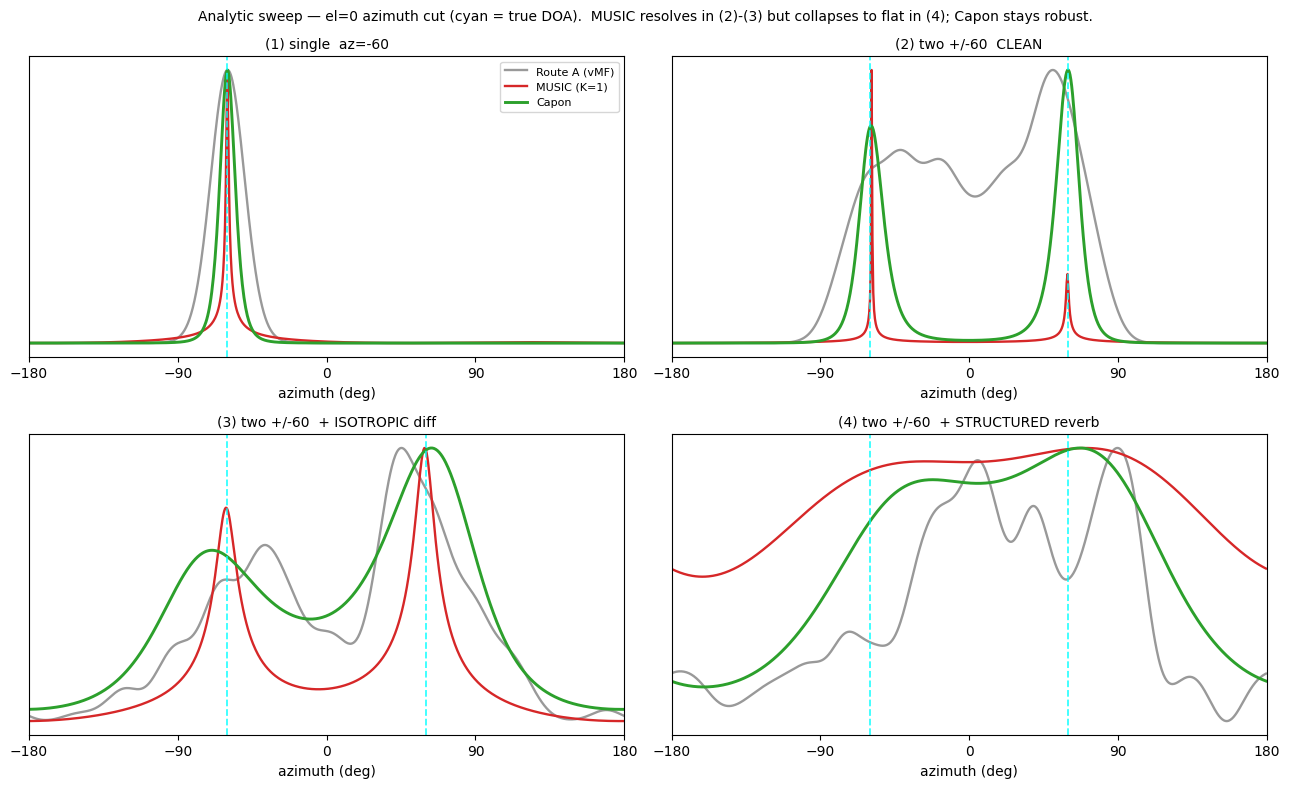

In [50]:
# =====================================================================
# Analytic sweep: Route A vs MUSIC vs Capon across conditions
# (snapshot/covariance level, no STFT — isolates the DOA estimator)
# =====================================================================
KAPPA, SHARP_A, LOAD_A, BETA, GAP = 40.0, 2.5, 0.02, 0.5, 2.0
wh = np.array([1., np.sqrt(3), np.sqrt(3), np.sqrt(3)]); WH = np.diag(wh)
def st(az, el=0.0):
    az, el = np.deg2rad(az), np.deg2rad(el)
    return np.array([1, np.sin(az)*np.cos(el), np.sin(el), np.cos(az)*np.cos(el)], complex)
azr = np.arange(-180, 180, 0.5)
Awr = np.stack([st(a) for a in azr])*wh[None]; Awr /= np.linalg.norm(Awr, axis=1, keepdims=True)
rdir = np.stack([np.cos(np.deg2rad(azr)), np.sin(np.deg2rad(azr)), np.zeros_like(azr)], 1)

def gen(sources, N=400, refl=(), diffuse=0.0, n_diff=40, noise=0.02, seed=1):
    rng = np.random.default_rng(seed); X = np.zeros((4, N), complex)
    def add(az, el, p):
        s = (rng.standard_normal(N)+1j*rng.standard_normal(N))/np.sqrt(2)*np.sqrt(p)
        return st(az, el)[:, None]*s[None, :]
    for az, el, p in sources: X += add(az, el, p)
    for az, el, p in refl:    X += add(az, el, p)
    for _ in range(n_diff if diffuse > 0 else 0):
        X += add(rng.uniform(-180, 180), np.degrees(np.arcsin(rng.uniform(-1, 1))), diffuse/n_diff)
    if noise > 0: X += (rng.standard_normal((4, N))+1j*rng.standard_normal((4, N)))/np.sqrt(2)*np.sqrt(noise)
    return X
def A_(X):
    W, YZX = X[0], X[1:]; I = 2*np.real(np.conj(W)[None]*YZX); Ix = I[[2, 0, 1], :]
    nr = np.linalg.norm(Ix, axis=0); d = Ix/np.maximum(nr, 1e-9)
    q = (nr[None]*np.exp(KAPPA*(rdir@d))).sum(1); return q/q.sum()
def C_(X):
    Rw = WH@(X@X.conj().T/X.shape[1])@WH.T
    Rl = Rw+LOAD_A*np.trace(Rw).real/4*np.eye(4)
    b = np.einsum("ri,ij,rj->r", Awr.conj(), np.linalg.inv(Rl), Awr).real.clip(1e-9)
    q = b**(-SHARP_A); return q/q.sum()
def M_(X):
    Rw = WH@(X@X.conj().T/X.shape[1])@WH.T
    ev, V = np.linalg.eigh(Rw); evd, Vd = ev.real.clip(0)[::-1], V[:, ::-1]
    rt = evd[:-1]/np.maximum(evd[1:], 1e-9); gi = int(np.argmax(rt))
    K = min(max((gi+1) if rt[gi] > GAP else 0, 0), 3); nz = (np.arange(4) >= K).astype(float)
    bt = np.einsum("ri,ij,rj->r", Awr.conj(), Rw, Awr).real.clip(0)
    mu = 1/((np.abs(Awr.conj()@Vd)**2*nz[None]).sum(1)+1e-9)
    q = (bt/bt.max())*((mu/mu.max())**BETA); return q/q.sum(), K

scenes = [
    ("(1) single  az=-60",              dict(sources=[(-60, 0, 1.)])),
    ("(2) two +/-60  CLEAN",            dict(sources=[(-60, 0, 1.), (60, 0, 1.)])),
    ("(3) two +/-60  + ISOTROPIC diff", dict(sources=[(-60, 0, 1.), (60, 0, 1.)], diffuse=1.5)),
    ("(4) two +/-60  + STRUCTURED reverb", dict(sources=[(-60, 0, 1.), (60, 0, 1.)],
        refl=[(15, 25, .7), (140, -15, .7), (-110, 35, .6), (95, 10, .6), (-30, -40, .5), (170, 5, .5)], diffuse=.6)),
]
fig2, axs = plt.subplots(2, 2, figsize=(13, 8)); axs = axs.ravel()
for ax, (name, kw) in zip(axs, scenes):
    X = gen(**kw); qA = A_(X); qC = C_(X); qM, K = M_(X)
    truth = sorted(a for a, e, p in kw["sources"])
    ax.plot(azr, qA/qA.max(), color="#999", lw=1.7, label="Route A (vMF)")
    ax.plot(azr, qM/qM.max(), color="#d62728", lw=1.7, label=f"MUSIC (K={K})")
    ax.plot(azr, qC/qC.max(), color="#2ca02c", lw=2.1, label="Capon")
    for a in truth: ax.axvline(a, ls="--", color="cyan", lw=1.3, alpha=.8)
    ax.set_title(name, fontsize=10); ax.set_xlim(-180, 180); ax.set_xticks(range(-180, 181, 90))
    ax.set_yticks([]); ax.set_xlabel("azimuth (deg)")
axs[0].legend(fontsize=8, loc="upper right")
fig2.suptitle("Analytic sweep — el=0 azimuth cut (cyan = true DOA).  "
              "MUSIC resolves in (2)-(3) but collapses to flat in (4); Capon stays robust.", fontsize=10)
plt.tight_layout()
plt.show()